<font size=6><b> Lec05. 다중분류 - 와인 예측
* https://www.kaggle.com/competitions/bike-sharing-demand/data

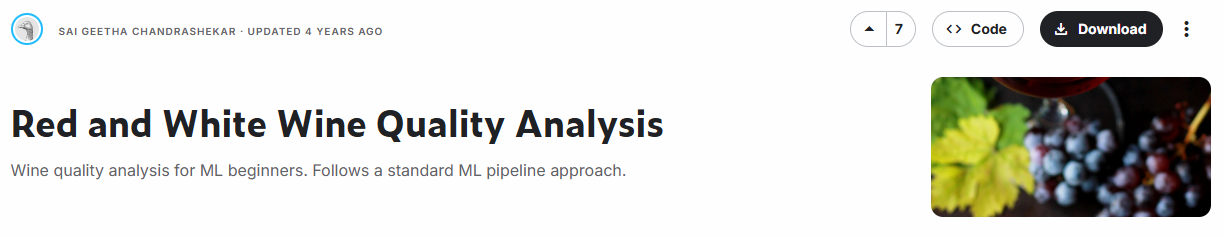

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LogisticRegression          # 선형모델
from sklearn.tree import DecisionTreeClassifier              # 트리모델
from sklearn.ensemble import RandomForestClassifier          # 배깅모델   : 데이터N,  똑같은모델N(앙상블)
from lightgbm import LGBMClassifier                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBClassifier

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import accuracy_score,      f1_score,  precision_score , recall_score,         roc_auc_score
from sklearn.metrics import                                 precision_recall_curve,                 roc_curve
from sklearn.metrics import classification_report,          confusion_matrix

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# Wine Data Load

* ref : https://www.kaggle.com/competitions/bike-sharing-demand/data


In [2]:
red = pd.read_csv("./data/winequality-red.csv", sep=';')
white = pd.read_csv("./data/winequality-white.csv", sep=';')

In [3]:
red.shape, white.shape

((1599, 12), (4898, 12))

## 데이터프레임 구조 확인

In [4]:
red.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
white.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [6]:
# red['type'] = 1
# white['type'] = 0
# df = pd.concat([red, white], axis = 0)
# df.shape

(6497, 13)

In [7]:
# df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 710.6 KB


In [8]:
red['quality'].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

In [ ]:
white['quality'].value_counts().sort_index()

In [9]:
# 1. 조건 정의 (isin을 써서 가독성과 속도를 모두 잡습니다)
conditions = [
    red['quality']==3,
    red['quality']==4,
    red['quality']==5,
    red['quality']==6,
    red['quality']==7,
    red['quality']==8,
    red['quality']==9
]

# 2. 결과 정의
choices = [0,1,2,3,4,5,6]

# 3. 한 번에 할당 (초기화 0을 default 파라미터로 해결)
red['target'] = np.select(conditions, choices, default=0)

In [ ]:
# 1. 조건 정의 (isin을 써서 가독성과 속도를 모두 잡습니다)
conditions = [
    red['quality']==3,
    red['quality']==4,
    red['quality']==5,
    red['quality']==6,
    red['quality']==7,
    red['quality']==8,
    red['quality']==9
]

# 2. 결과 정의
choices = [0,1,2,3,4,5,6]

# 3. 한 번에 할당 (초기화 0을 default 파라미터로 해결)
red['target'] = np.select(conditions, choices, default=0)

In [10]:
df[['quality', 'target']].value_counts().sort_index()

quality  target
3        0           30
4        1          216
5        2         2138
6        3         2836
7        4         1079
8        5          193
9        6            5
Name: count, dtype: int64

# EDA & Feature Engineering

🍷 와인 품질 데이터 변수 정의서 (Wine Quality Features)
<div style="padding: 15px; border-left: 5px solid #e74c3c; background-color: #fdf2f2; margin-bottom: 20px;"> <strong>💡 분석 가이드:</strong> 변수명 (Feature),분류,상세 설명 (Description)
Fixed Acidity,"<span style=""color: #e74c3c;"">Acid</span>",고정 산도: 와인의 기초적인 신맛과 구조를 잡는 비휘발성 산.
Volatile Acidity,"<span style=""color: #e74c3c;"">Acid</span>",휘발성 산도: 아세트산 함량. 너무 높으면 식초 향이 나며 품질 저하.
Citric Acid,"<span style=""color: #e74c3c;"">Acid</span>",구연산: 소량 함유되며 와인에 신선함과 풍미를 더함.
Residual Sugar,"<span style=""color: #f1c40f;"">Sugar</span>",잔당: 발효 후 남은 당분. 45g/L 이상 시 '스위트 와인'으로 분류.
Chlorides,"<span style=""color: #7f8c8d;"">Salt</span>",염화물: 와인에 포함된 소금기(염분)의 양.
Free Sulfur Dioxide,"<span style=""color: #9b59b6;"">Sulfur</span>",유리 이산화황: 미생물 증식 및 산화 방지용 핵심 보존제.
Total Sulfur Dioxide,"<span style=""color: #9b59b6;"">Sulfur</span>",총 이산화황: 유리/결합 이산화황의 총량. 50ppm 초과 시 황 냄새 감지.
Density,"<span style=""color: #3498db;"">Physic</span>",밀도: 알코올/당분에 의해 결정. 물(1.0) 기준 미세하게 변함.
pH,"<span style=""color: #e74c3c;"">Acid</span>",pH: 산성도(0~14). 대부분의 와인은 3~4 사이의 산성을 띰.
Sulphates,"<span style=""color: #9b59b6;"">Sulfur</span>",황산염: 이산화황 가스 생성을 돕는 항균 및 항산화 첨가제.
Alcohol,"<span style=""color: #2ecc71;"">Energy</span>",알코올: 도수. 품질 점수와 가장 강한 양(+)의 상관관계를 보임. </div>

In [11]:
# from ydata_profiling import ProfileReport
# res = ProfileReport(df, title="wine Report")
# res.to_file('wine_report.html')

In [12]:
df = df.rename(columns={'fixed acidity': 'fixed_acidity',
                        'volatile acidity': 'volatile_acidity',
                        'citric acid': 'citric_acid',
                        'residual sugar': 'residual_sugar',
                        'free sulfur dioxide':'free_sulfur_dioxide',
                        'total sulfur dioxide':'total_sulfur_dioxide'
                       })

In [15]:
# 1. 조건 정의 (isin을 써서 가독성과 속도를 모두 잡습니다)
conditions = [
    df['residual_sugar'] < 1,
    df['residual_sugar'] >= 45,
]

# 2. 결과 정의
choices = [1, 2]

# 3. 한 번에 할당 (초기화 0을 default 파라미터로 해결)
df['sweet'] = np.select(conditions, choices, default=0)

In [16]:
df['sweet'].value_counts()

sweet
0    6417
1      79
2       1
Name: count, dtype: int64

In [17]:
df['bound_sulfur_dioxide'] = df['total_sulfur_dioxide'] - df['free_sulfur_dioxide']

In [18]:
# 1. 조건 정의 (isin을 써서 가독성과 속도를 모두 잡습니다)
conditions = [
    df['citric_acid'] == 0,
]

# 2. 결과 정의
choices = [1]

# 3. 한 번에 할당 (초기화 0을 default 파라미터로 해결)
df['citric0'] = np.select(conditions, choices, default=0)

In [19]:
df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type', 'target', 'sweet',
       'bound_sulfur_dioxide', 'citric0'],
      dtype='object')

In [13]:
cols = [c for c in df.columns if c != 'target']
fig, axes = plt.subplots(nrows=len(cols), ncols=2, figsize=(12, 4 * len(cols)))

colors = ["#E74C3C", "#3498DB", "#2ECC71", "#F1C40F", "#9B59B6", "#E67E22", "#1ABC9C"]

# 실제 데이터에 존재하는 타겟 값 확인 (에러 방지)
target_values = sorted(df['target'].unique())

for i, col in enumerate(cols):
    # 1. 왼쪽: 히스토그램 (Histplot)
    for idx, target_val in enumerate(target_values):
        sns.histplot(df[df['target'] == target_val][col], 
                     kde=False, 
                     color=colors[idx % len(colors)], 
                     ax=axes[i, 0],
                     element="step",
                     alpha=0.3)
    
    # 각 피쳐별 타겟의 평균값을 제목에 표시 (냉철한 수치 확인)
    means = df.groupby('target')[col].mean()
    mean_str = ", ".join([f"{v:.2f}" for v in means.values])
    axes[i, 0].set_title(f"{col} - Means by Target: [{mean_str}]")

    # 2. 오른쪽: 박스플롯 (Boxplot)
    sns.boxplot(x="target", y=col, data=df, ax=axes[i, 1], palette=colors)
    axes[i, 1].set_title(f"{col} Boxplot")

# --- 범례 통합 작업 ---
# 마지막 axes에서 핸들과 라벨을 가져와 전체 범례 생성
handles, labels = axes[0, 0].get_legend_handles_labels()
# 만약 label이 안 잡힌다면 수동으로 생성 (Class 0~6)
if not labels:
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], color=colors[i], lw=4) for i in range(len(target_values))]
    labels = [f"Class {v}" for v in target_values]

# 상단에 범례 배치 (전체 그림 기준)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=7, fontsize=12)

plt.tight_layout()
plt.savefig("all_features_analysis.png", dpi=300, bbox_inches='tight')
plt.close()

In [14]:
# 1. 분석할 컬럼 추출 (target 제외)
features = [col for col in df.columns if col != 'target']
target_values = sorted(df['target'].unique())

# 2. 도화지 준비 (피쳐 개수에 맞춰 유동적으로 행 설정)
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols  # 올림 연산

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 4 * n_rows))
axes_flat = axes.flatten()

# 고유한 7가지 색상 설정
colors = ["#E74C3C", "#3498DB", "#2ECC71", "#F1C40F", "#9B59B6", "#E67E22", "#1ABC9C"]
palette = dict(zip(target_values, colors[:len(target_values)]))

# 3. 루프를 이용한 렌더링
for i, col in enumerate(features):
    # legend=False를 주어 개별 그래프의 범례 생성을 막습니다.
    sns.histplot(data=df, x=col, hue='target', ax=axes_flat[i], 
                 kde=True, element="bars", multiple='dodge', 
                 palette=palette, legend=False)
    
    axes_flat[i].set_title(f"Distribution of {col}", fontsize=12)
    axes_flat[i].set_xlabel("")

# 4. 빈 칸 삭제 (피쳐 개수가 ncols의 배수가 아닐 경우)
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# 5. 통합 범례 (Figure 상단에 단 하나만 배치)
handles = [Line2D([0], [0], color=palette[t], lw=4) for t in target_values]
labels = [f"Class {t}" for t in target_values]
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.01), 
           ncol=len(target_values), fontsize=13, frameon=False)

# 6. 레이아웃 최적화 및 저장
plt.tight_layout(rect=[0, 0, 1, 0.98]) # 범례가 들어갈 상단 여백 확보
plt.savefig("all_features_analysis_final.png", dpi=300, bbox_inches='tight')
plt.close()

## 상관계수 : heatmap 
* 피어슨(Pearson) 상관계수 : 선형  --> 히트맵은 기본이 선형
* 스피어만(Spearman) 상관계수 : 비선형

In [20]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, fmt=".2f", mask=mask, cmap='coolwarm') 
plt.savefig("all_features_heat_map.png", dpi=300, bbox_inches='tight')
plt.close()

# 모델 학습 및 평가

## [Quiz] train_test 분리
* test 데이터 크기는 전체 데이터의 20% 사용

In [21]:

def handle_outliers(df, method='clip', columns=None):
    """
    method: 'clip' (범위 제한) 또는 'remove' (행 삭제)
    columns: 처리할 컬럼 리스트와 해당 범위 (dict 형태 추천)
    """
    df_cp = df.copy()
    if columns is None:
        # 와인 데이터셋 예시 범위 (도메인 지식 기반)
        columns = {
            'volatile_acidity': (0, 1.2), # 식초 냄새가 너무 심한 것 차단
            'residual_sugar': (0, 20.0),   # 너무 단 와인 제외/억제
            'chlorides': (0, 0.2)
            
        }

    for col, (low, high) in columns.items():
        if col in df_cp.columns:
            if method == 'clip':
                # 1. 클리핑: 범위를 벗어나는 값을 경계값으로 고정
                df_cp[col] = np.clip(df_cp[col], low, high)
            elif method == 'remove':
                # 2. 제거: 범위를 벗어나는 행을 아예 삭제
                df_cp = df_cp[(df_cp[col] >= low) & (df_cp[col] <= high)]
    
    return df_cp.reset_index(drop=True)

# 로그 변환 함수 정의 (특정 컬럼만 골라서 변환하도록 설정)
def log_transform_cols(X):
    X_cp = X.copy()
    col_list = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'bound_sulfur_dioxide']
    # 컬럼 존재 여부 체크 로직을 넣으면 더 견고해짐
    target_cols = [c for c in col_list if c in X_cp.columns]
    X_cp[target_cols] = np.log1p(X_cp[target_cols])
    return X_cp



In [22]:
#  Kfold 적용한 함수
from sklearn.model_selection import KFold
from sklearn.preprocessing import FunctionTransformer

# [최상위 레벨] 모델 파이프라인 생성 함수 (필요시 호출)
def get_pipeline(scaler, model):
    return Pipeline([
        
        ('log', FunctionTransformer(log_transform_cols)),
        ('scaler', scaler if scaler else 'passthrough'),
        ('model', model)
    ])

def train_and_evaluate(X_train_full, X_test, y_train_full, y_test):
   
    # 모델 및 스케일러 리스트
    scaler_list = [None, StandardScaler(), MinMaxScaler(), RobustScaler()]
    model_list = [
        LogisticRegression(max_iter=1000), 
        XGBClassifier(random_state=4567), 
        LGBMClassifier(random_state=4567, verbosity=-1, class_weight='balanced')
    ]

    best_score = 0
    best_pipe = None
    best_params = ""

    for scaler in scaler_list:
        for model in model_list:
            model_name = model.__class__.__name__
            scaler_name = scaler.__class__.__name__ if scaler else "None"
            print(f"\n🚀 Testing: {scaler_name} + {model_name}")
            
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=4875)
            cv_scores = []
            
            for i, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
                X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
                y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

                pipe = get_pipeline(scaler, model)
                pipe.fit(X_tr, y_tr)
                
                val_pred = pipe.predict(X_val)
                f1 = f1_score(y_val, val_pred, average='macro')
                cv_scores.append(f1)
                print(f"   - Fold {i+1}: F1 = {f1:.4f}") # 1~5차 개별 점수 출력
            
            avg_f1 = np.mean(cv_scores)
            print(f"   ⭐ Average CV F1: {avg_f1:.4f}")

            if avg_f1 > best_score:
                best_score = avg_f1
                best_params = f"{scaler_name} + {model_name}"
                best_pipe = get_pipeline(scaler, model)
                best_pipe.fit(X_train_full, y_train_full)

    # --- 최적 모델 상세 리포트 ---
    print("\n" + "="*50)
    print(f"🏆 BEST MODEL: {best_params}")
    print("="*50)
    
    final_pred = best_pipe.predict(X_test)
    
    print("\n[1. Classification Report]")
    print(classification_report(y_test, final_pred))
    
    print("\n[2. Confusion Matrix]")
    cm = confusion_matrix(y_test, final_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {best_params}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # 3. 샘플 데이터 대조 확인 (디버깅용)
    print("\n[3. Prediction vs Actual Sample]")
    comparison_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': final_pred})
    print(comparison_df.head(10))
    
    return best_pipe, best_score, X_train_full, X_test, y_train_full, y_test


In [23]:
df = df.drop('quality', axis=1)

In [24]:
y = df['target']
X = df.drop('target', axis=1)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2,  random_state=4567, stratify=y)

In [25]:
df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'type', 'target', 'sweet',
       'bound_sulfur_dioxide', 'citric0'],
      dtype='object')


🚀 Testing: None + LogisticRegression
   - Fold 1: F1 = 0.1925
   - Fold 2: F1 = 0.2029
   - Fold 3: F1 = 0.2543
   - Fold 4: F1 = 0.2221
   - Fold 5: F1 = 0.2035
   ⭐ Average CV F1: 0.2151

🚀 Testing: None + XGBClassifier
   - Fold 1: F1 = 0.3622
   - Fold 2: F1 = 0.3549
   - Fold 3: F1 = 0.4480
   - Fold 4: F1 = 0.3779
   - Fold 5: F1 = 0.3778
   ⭐ Average CV F1: 0.3841

🚀 Testing: None + LGBMClassifier
   - Fold 1: F1 = 0.3571
   - Fold 2: F1 = 0.3703
   - Fold 3: F1 = 0.3903
   - Fold 4: F1 = 0.3605
   - Fold 5: F1 = 0.3684
   ⭐ Average CV F1: 0.3693

🚀 Testing: StandardScaler + LogisticRegression
   - Fold 1: F1 = 0.2273
   - Fold 2: F1 = 0.2299
   - Fold 3: F1 = 0.2777
   - Fold 4: F1 = 0.2396
   - Fold 5: F1 = 0.2136
   ⭐ Average CV F1: 0.2376

🚀 Testing: StandardScaler + XGBClassifier
   - Fold 1: F1 = 0.3622
   - Fold 2: F1 = 0.3549
   - Fold 3: F1 = 0.4480
   - Fold 4: F1 = 0.3779
   - Fold 5: F1 = 0.3778
   ⭐ Average CV F1: 0.3841

🚀 Testing: StandardScaler + LGBMClassifier


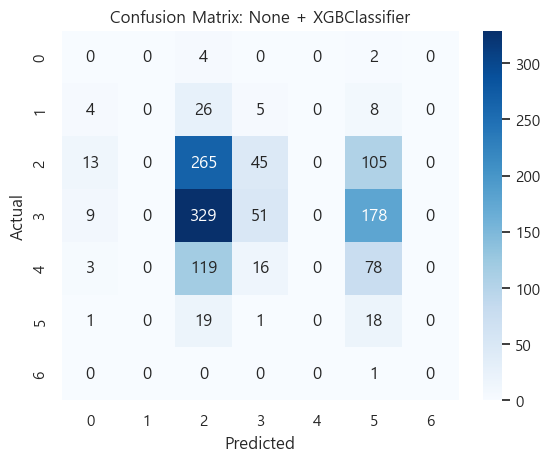


[3. Prediction vs Actual Sample]
   Actual  Predicted
0       2          2
1       3          5
2       2          2
3       3          5
4       4          2
5       4          2
6       3          5
7       3          3
8       3          2
9       4          2


In [26]:
best_pipe, best_score, X_train, X_test, y_train, y_test = train_and_evaluate(X_train_full, X_test, y_train_full, y_test)

In [27]:
X_train_full_log = log_transform_cols(X_train_full)
X_test_log = log_transform_cols(X_test)

In [30]:
tmp = pd.concat([X_train_full_log, y_train_full], axis = 1)

In [31]:
cols = [c for c in tmp.columns if c != 'target']
fig, axes = plt.subplots(nrows=len(cols), ncols=2, figsize=(12, 4 * len(cols)))

colors = ["#E74C3C", "#3498DB", "#2ECC71", "#F1C40F", "#9B59B6", "#E67E22", "#1ABC9C"]

# 실제 데이터에 존재하는 타겟 값 확인 (에러 방지)
target_values = sorted(tmp['target'].unique())

for i, col in enumerate(cols):
    # 1. 왼쪽: 히스토그램 (Histplot)
    for idx, target_val in enumerate(target_values):
        sns.histplot(tmp[tmp['target'] == target_val][col], 
                     kde=False, 
                     color=colors[idx % len(colors)], 
                     ax=axes[i, 0],
                     element="step",
                     alpha=0.3)
    
    # 각 피쳐별 타겟의 평균값을 제목에 표시 (냉철한 수치 확인)
    means = tmp.groupby('target')[col].mean()
    mean_str = ", ".join([f"{v:.2f}" for v in means.values])
    axes[i, 0].set_title(f"{col} - Means by Target: [{mean_str}]")

    # 2. 오른쪽: 박스플롯 (Boxplot)
    sns.boxplot(x="target", y=col, data=tmp, ax=axes[i, 1], palette=colors)
    axes[i, 1].set_title(f"{col} Boxplot")

# --- 범례 통합 작업 ---
# 마지막 axes에서 핸들과 라벨을 가져와 전체 범례 생성
handles, labels = axes[0, 0].get_legend_handles_labels()
# 만약 label이 안 잡힌다면 수동으로 생성 (Class 0~6)
if not labels:
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], color=colors[i], lw=4) for i in range(len(target_values))]
    labels = [f"Class {v}" for v in target_values]

# 상단에 범례 배치 (전체 그림 기준)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=7, fontsize=12)

plt.tight_layout()
plt.savefig("log_transform_analysis.png", dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
best_pipe, best_score, X_train, X_test, y_train, y_test = train_and_evaluate(X_train_full_log, X_test_log, y_train_full, y_test)

In [ ]:
best_pipe, best_score, X_train, X_test, y_train, y_test = train_and_evaluate(X_train_full_log, X_test_log, y_train_full, y_test)